# Logistic Regression and KNN: Building Intuition

Part 1 builds logistic regression from the sigmoid up to 2D decision boundaries.
Part 2 uses KNN on 2D points to show why feature scaling matters.

Move the sliders, then answer the questions under each plot.
Requires `ipywidgets` (`pip install ipywidgets`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, FloatLogSlider, IntSlider, Dropdown
from sklearn.datasets import make_moons, make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

%matplotlib inline
rng = np.random.default_rng(0)
CMAP = "bwr"


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Part 1. Logistic regression

## 1.1 The sigmoid

Logistic regression models a probability:

$$P(y=1 \mid x) = \sigma(wx + b), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

The model predicts class 1 when $P \ge 0.5$, i.e. when $wx + b \ge 0$. The decision boundary is $x = -b/w$.

In [2]:
xs = np.linspace(-10, 10, 400)

@interact(w=FloatSlider(value=1, min=-5, max=5, step=0.1),
          b=FloatSlider(value=0, min=-10, max=10, step=0.5))
def plot_sigmoid(w, b):
    plt.figure(figsize=(7, 4))
    plt.plot(xs, sigmoid(w * xs + b), "k")
    plt.axhline(0.5, color="gray", ls="--", lw=1)
    if w != 0:
        plt.axvline(-b / w, color="red", ls=":", label=f"boundary x = {-b / w:.2f}")
        plt.legend(loc="upper left")
    plt.ylim(-0.05, 1.05)
    plt.xlabel("x")
    plt.ylabel("P(y = 1 | x)")
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='w', max=5.0, min=-5.0), FloatSlider(value=0.0, descr…

- What does $w$ control? What does $b$ control?
- What happens when $w < 0$? When $w = 0$?
- What does the curve look like when $|w|$ is very large?

## 1.2 Odds and log-odds

Inverting the sigmoid shows that the model is linear in the **log-odds**:

$$\log \frac{p}{1-p} = wx + b$$

Increasing $x$ by one unit adds $w$ to the log-odds, i.e. multiplies the odds by $e^{w}$.

In [3]:
for p in [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]:
    print(f"p = {p:.2f}   odds = {p / (1 - p):7.3f}   log-odds = {np.log(p / (1 - p)):6.2f}")

p = 0.01   odds =   0.010   log-odds =  -4.60
p = 0.10   odds =   0.111   log-odds =  -2.20
p = 0.25   odds =   0.333   log-odds =  -1.10
p = 0.50   odds =   1.000   log-odds =   0.00
p = 0.75   odds =   3.000   log-odds =   1.10
p = 0.90   odds =   9.000   log-odds =   2.20
p = 0.99   odds =  99.000   log-odds =   4.60


## 1.3 Fitting: maximum likelihood

Given labeled data, we pick $(w, b)$ that make the observed labels most likely. Equivalently, we minimize the
negative log-likelihood (cross-entropy):

$$L(w, b) = -\frac{1}{n}\sum_{i=1}^n \Big[y_i \log p_i + (1-y_i)\log(1-p_i)\Big], \qquad p_i = \sigma(wx_i + b)$$

A point pays a large loss when the model is confident and wrong. In the left plot, marker size is proportional to
each point's loss. The right plot shows $L$ over all $(w, b)$; the star is the optimum found by scikit-learn.

In [4]:
n = 40
x1d = np.concatenate([rng.normal(-1.5, 1.2, n), rng.normal(1.5, 1.2, n)])
y1d = np.concatenate([np.zeros(n), np.ones(n)])


def point_loss(w, b, x, y):
    p = np.clip(sigmoid(w * x + b), 1e-12, 1 - 1e-12)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))


# loss surface on a grid of (w, b)
W, B = np.meshgrid(np.linspace(-1, 6, 150), np.linspace(-4, 4, 150))
L = point_loss(W[..., None], B[..., None], x1d, y1d).mean(axis=-1)

clf1d = LogisticRegression(C=np.inf).fit(x1d.reshape(-1, 1), y1d)
w_hat, b_hat = clf1d.coef_[0, 0], clf1d.intercept_[0]
print(f"MLE: w = {w_hat:.3f}, b = {b_hat:.3f}, loss = {point_loss(w_hat, b_hat, x1d, y1d).mean():.3f}")

MLE: w = 3.069, b = 0.298, loss = 0.156


In [5]:
@interact(w=FloatSlider(value=0.5, min=-1, max=6, step=0.1),
          b=FloatSlider(value=2, min=-4, max=4, step=0.1))
def fit_by_hand(w, b):
    losses = point_loss(w, b, x1d, y1d)
    xs = np.linspace(-6, 6, 300)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].scatter(x1d, y1d, c=y1d, cmap=CMAP, s=20 + 60 * losses, alpha=0.6, edgecolor="k")
    ax[0].plot(xs, sigmoid(w * xs + b), "k")
    ax[0].plot(xs, sigmoid(w_hat * xs + b_hat), "g--", lw=1, label="MLE")
    ax[0].set(xlabel="x", ylabel="y  /  P(y = 1 | x)", title=f"loss = {losses.mean():.3f}")
    ax[0].legend(loc="center right")

    cs = ax[1].contour(W, B, L, levels=30, cmap="viridis")
    ax[1].plot(w, b, "ro", ms=8, label="your (w, b)")
    ax[1].plot(w_hat, b_hat, "k*", ms=14, label="MLE")
    ax[1].set(xlabel="w", ylabel="b", title="loss surface L(w, b)")
    ax[1].legend()
    plt.show()

interactive(children=(FloatSlider(value=0.5, description='w', max=6.0, min=-1.0), FloatSlider(value=2.0, descr…

- Try to reach the star by hand. Which points have large markers when $(w, b)$ is far from it?
- The loss surface is convex: a single valley, no local minima. Why does that matter for optimization?

## 1.4 Gradient descent

There is no closed form for the optimum, so we descend the loss surface. The gradient has a simple form:

$$\frac{\partial L}{\partial w} = \frac{1}{n}\sum_i (p_i - y_i)\,x_i, \qquad \frac{\partial L}{\partial b} = \frac{1}{n}\sum_i (p_i - y_i)$$

Each step moves $(w, b)$ against the gradient, scaled by the learning rate $\eta$.

In [ ]:
def gradient_descent_1d(x, y, lr, steps, w0=0.0, b0=3.5):
    w, b = w0, b0
    path = [(w, b)]
    for _ in range(steps):
        r = sigmoid(w * x + b) - y
        w, b = w - lr * np.mean(r * x), b - lr * np.mean(r)
        path.append((w, b))
    return np.array(path)


@interact(lr=FloatLogSlider(value=0.5, base=10, min=-2, max=1.5, step=0.1),
          steps=IntSlider(value=30, min=1, max=300))
def show_gd(lr, steps):
    path = gradient_descent_1d(x1d, y1d, lr, steps)
    loss = [point_loss(w, b, x1d, y1d).mean() for w, b in path]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].contour(W, B, L, levels=30, cmap="viridis")
    ax[0].plot(path[:, 0], path[:, 1], "r.-", lw=1, ms=4)
    ax[0].plot(w_hat, b_hat, "k*", ms=14)
    ax[0].set(xlim=(W.min(), W.max()), ylim=(B.min(), B.max()), xlabel="w", ylabel="b",
              title=f"lr = {lr:.3f}")

    ax[1].plot(loss)
    ax[1].set(xlabel="iteration", ylabel="loss", title=f"final loss = {loss[-1]:.4f}")
    plt.show()

interactive(children=(FloatLogSlider(value=0.5, description='lr', max=1.5, min=-2.0), IntSlider(value=30, desc…

- Find a learning rate that is too small (slow) and one that is too large (oscillates or diverges).
- Each step is perpendicular to the contour line it starts from. Verify this on the plot.

## 1.5 Two features: a linear decision boundary

With features $x = (x_1, x_2)$ the model is $P(y=1 \mid x) = \sigma(w_1 x_1 + w_2 x_2 + b)$.
The boundary $w_1 x_1 + w_2 x_2 + b = 0$ is a line. The vector $w$ is perpendicular to it and points toward class 1;
its length controls how quickly the probability changes across the line.

In [7]:
X2 = np.vstack([rng.normal([-1, -1], 1, (100, 2)), rng.normal([1.5, 1.5], 1, (100, 2))])
y2 = np.r_[np.zeros(100), np.ones(100)]

g1, g2 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
grid = np.c_[g1.ravel(), g2.ravel()]


def plot_prob(ax, prob, X, y, title):
    im = ax.contourf(g1, g2, prob.reshape(g1.shape), levels=np.linspace(0, 1, 11), cmap=CMAP, alpha=0.4)
    ax.contour(g1, g2, prob.reshape(g1.shape), levels=[0.5], colors="k")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, edgecolor="k", s=20)
    ax.set(xlim=(-5, 5), ylim=(-5, 5), aspect="equal", xlabel="$x_1$", ylabel="$x_2$", title=title)
    return im


@interact(w1=FloatSlider(value=1, min=-5, max=5, step=0.1),
          w2=FloatSlider(value=0, min=-5, max=5, step=0.1),
          b=FloatSlider(value=0, min=-5, max=5, step=0.1))
def boundary_by_hand(w1, w2, b):
    prob = sigmoid(grid @ np.array([w1, w2]) + b)
    p = sigmoid(X2 @ np.array([w1, w2]) + b)
    loss = point_loss(1, 0, X2 @ np.array([w1, w2]) + b, y2).mean()
    acc = np.mean((p >= 0.5) == y2)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = plot_prob(ax, prob, X2, y2, f"loss = {loss:.3f}, accuracy = {acc:.2f}")
    ax.arrow(0, 0, w1, w2, color="k", width=0.05, length_includes_head=True)
    fig.colorbar(im, ax=ax, label="P(y = 1 | x)")
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='w1', max=5.0, min=-5.0), FloatSlider(value=0.0, desc…

- Keep the direction of $w$ fixed and increase its length. What changes, and what stays the same?
- Can you get a lower loss with the same accuracy? Why can loss improve when accuracy does not?

## 1.6 Regularization and the threshold

scikit-learn fits $(w, b)$ for us. Two knobs worth understanding:

- `C`: inverse regularization strength. Small `C` penalizes large $\|w\|$, giving flatter, less confident probabilities.
- The threshold $t$: we predict class 1 when $P \ge t$. Changing $t$ moves the boundary without refitting.

In [8]:
@interact(C=FloatLogSlider(value=1, base=10, min=-3, max=3, step=0.25),
          t=FloatSlider(value=0.5, min=0.05, max=0.95, step=0.05))
def regularization_threshold(C, t):
    clf = LogisticRegression(C=C).fit(X2, y2)
    prob = clf.predict_proba(grid)[:, 1]
    pred = clf.predict_proba(X2)[:, 1] >= t
    tp, fp = np.sum(pred & (y2 == 1)), np.sum(pred & (y2 == 0))
    fn, tn = np.sum(~pred & (y2 == 1)), np.sum(~pred & (y2 == 0))

    fig, ax = plt.subplots(figsize=(6, 5))
    plot_prob(ax, prob, X2, y2, f"C = {C:.3g},  ||w|| = {np.linalg.norm(clf.coef_):.2f}")
    ax.contour(g1, g2, prob.reshape(g1.shape), levels=[t], colors="g", linestyles="--")
    plt.show()
    print(f"threshold {t:.2f} (green):  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

interactive(children=(FloatLogSlider(value=1.0, description='C', max=3.0, min=-3.0, step=0.25), FloatSlider(va…

- As `C` decreases, what happens to $\|w\|$ and to the width of the color transition?
- Raising $t$ reduces false positives. What does it cost? When would you want that trade-off?

## 1.7 Non-linear boundaries

The boundary is linear **in the features**. Adding transformed features (e.g. $x_1^2, x_1x_2, x_2^2$) lets a linear
model draw curved boundaries in the original space.

In [9]:
Xc, yc = make_circles(300, noise=0.1, factor=0.4, random_state=0)
Xc *= 3


@interact(degree=IntSlider(value=1, min=1, max=6))
def polynomial_logistic(degree):
    #model = make_pipeline(PolynomialFeatures(degree), StandardScaler(), LogisticRegression(C=10, max_iter=5000))
    model = make_pipeline(PolynomialFeatures(degree), LogisticRegression(C=10, max_iter=5000))

    model.fit(Xc, yc)
    fig, ax = plt.subplots(figsize=(6, 5))
    plot_prob(ax, model.predict_proba(grid)[:, 1], Xc, yc,
              f"degree {degree}, train accuracy = {model.score(Xc, yc):.2f}")
    plt.show()

interactive(children=(IntSlider(value=1, description='degree', max=6, min=1), Output()), _dom_classes=('widget…

- What is the smallest degree that separates the circles? Which features make it possible?
- What starts to happen at high degree?

# Part 2. KNN and preprocessing

## 2.1 KNN in one sentence

To classify a point, find its $k$ nearest training points (Euclidean distance) and take a majority vote.

$$d(a, c) = \sqrt{(a_1 - c_1)^2 + (a_2 - c_2)^2}$$

The distance adds up squared differences across features, so **a feature with a larger numeric range dominates the
distance**, regardless of how useful it is.

## 2.2 The data

Two interleaved moons. Both features are needed to separate them. We then express $x_1$ in different units
(multiply by 1000 and add an offset), as if one column were measured in grams and the other in kilograms.
The information is identical; only the units changed.

In [10]:
Xm, ym = make_moons(400, noise=0.25, random_state=0)


def change_units(X, factor, offset=5000):
    X = X.copy()
    X[:, 0] = X[:, 0] * factor + offset
    return X


Xm_raw = change_units(Xm, 1000)
X_tr, X_te, y_tr, y_te = train_test_split(Xm_raw, ym, test_size=0.4, random_state=0)
print("feature means:", X_tr.mean(axis=0).round(2))
print("feature stds: ", X_tr.std(axis=0).round(2))

feature means: [5.48104e+03 2.10000e-01]
feature stds:  [8.7809e+02 5.4000e-01]


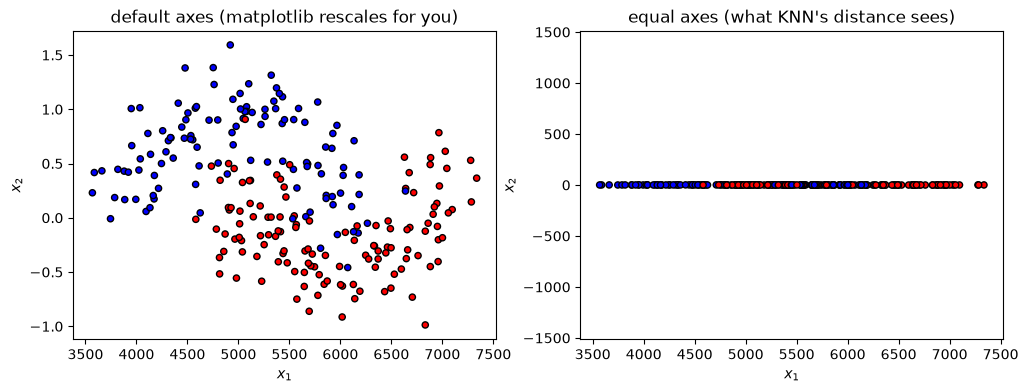

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=CMAP, edgecolor="k", s=20)
ax[0].set(xlabel="$x_1$", ylabel="$x_2$", title="default axes (matplotlib rescales for you)")
ax[1].scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=CMAP, edgecolor="k", s=20)
ax[1].set(xlabel="$x_1$", ylabel="$x_2$", title="equal axes (what KNN's distance sees)")
ax[1].set_aspect("equal", adjustable="datalim")
plt.show()

The left plot is misleading: matplotlib stretches each axis independently. On equal axes, the $x_2$ direction is
negligible, so neighbors are chosen almost entirely by $x_1$.

## 2.3 Interactive: units, k and preprocessing

Preprocessing options (statistics computed on the training set only):

| option | transform |
|---|---|
| none | $x$ |
| center | $x - \bar{x}$ |
| scale | $x / s$ |
| standardize | $(x - \bar{x}) / s$ |

In [12]:
def preprocess(X_train, X_test, method):
    mean, std = X_train.mean(axis=0), X_train.std(axis=0)
    if method in ("center", "standardize"):
        X_train, X_test = X_train - mean, X_test - mean
    if method in ("scale", "standardize"):
        X_train, X_test = X_train / std, X_test / std
    return X_train, X_test


@interact(factor=FloatLogSlider(value=1000, base=10, min=-3, max=4, step=0.5),
          k=IntSlider(value=15, min=1, max=60),
          method=Dropdown(options=["none", "center", "scale", "standardize"]))
def knn_preprocessing(factor, k, method):
    Xtr, Xte = change_units(X_tr, factor / 1000, 0), change_units(X_te, factor / 1000, 0)
    Ptr, Pte = preprocess(Xtr, Xte, method)
    knn = KNeighborsClassifier(n_neighbors=k).fit(Ptr, y_tr)

    # decision regions drawn in the original units
    a, c = np.meshgrid(np.linspace(Xtr[:, 0].min(), Xtr[:, 0].max(), 200),
                       np.linspace(Xtr[:, 1].min(), Xtr[:, 1].max(), 200))
    G = np.c_[a.ravel(), c.ravel()]
    _, PG = preprocess(Xtr, G, method)
    Z = knn.predict(PG).reshape(a.shape)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].contourf(a, c, Z, alpha=0.3, cmap=CMAP)
    ax[0].scatter(Xte[:, 0], Xte[:, 1], c=y_te, cmap=CMAP, edgecolor="k", s=20)
    ax[0].set(xlabel="$x_1$", ylabel="$x_2$",
              title=f"test accuracy = {knn.score(Pte, y_te):.3f}  (original units)")

    ax[1].scatter(Ptr[:, 0], Ptr[:, 1], c=y_tr, cmap=CMAP, edgecolor="k", s=20)
    ax[1].set(xlabel="$x_1$ (transformed)", ylabel="$x_2$ (transformed)",
              title="space where distances are computed")
    ax[1].set_aspect("equal", adjustable="datalim")
    plt.show()

interactive(children=(FloatLogSlider(value=1000.0, description='factor', min=-3.0, step=0.5), IntSlider(value=…

- With `factor = 1000` and `method = none`, what shape do the decision regions have? Why?
- Compare `none` with `center`. Does centering change the accuracy? Explain using the distance formula.
- Compare `none` with `scale`, and `scale` with `standardize`. Which operation actually matters for KNN?
- Set `factor = 0.001`. Which feature dominates now? Does `standardize` give the same result for every factor?

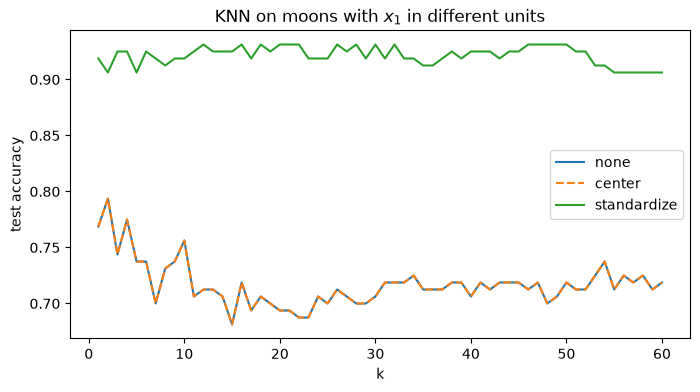

In [13]:
ks = np.arange(1, 61)
fig, ax = plt.subplots(figsize=(8, 4))
for method in ["none", "center", "standardize"]:
    Ptr, Pte = preprocess(X_tr, X_te, method)
    acc = [KNeighborsClassifier(n_neighbors=k).fit(Ptr, y_tr).score(Pte, y_te) for k in ks]
    ax.plot(ks, acc, label=method, ls="--" if method == "center" else "-")
ax.set(xlabel="k", ylabel="test accuracy", title="KNN on moons with $x_1$ in different units")
ax.legend()
plt.show()

Centering alone overlaps exactly with `none`: distances are invariant to shifting all points. Scaling is what fixes
KNN, because it puts features on comparable ranges. No choice of $k$ compensates for bad scaling.

In practice, use a pipeline so the scaler is fit on the training data only (fitting it on the test set leaks
information):

In [14]:
knn_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15))
knn_pipe.fit(X_tr, y_tr)
print(f"pipeline test accuracy: {knn_pipe.score(X_te, y_te):.3f}")

pipeline test accuracy: 0.925


## 2.4 Where centering does matter: gradient descent

Centering is irrelevant for KNN, but it matters for models trained by gradient descent, such as logistic regression.
If features have a large mean, $w$ and $b$ become strongly coupled (changing one requires compensating with the
other), and the loss surface turns into a long narrow valley where gradient descent crawls.

Below, gradient descent runs on the same moons data with three preprocessings. Each run uses the standard safe step size for
its own data ($\eta = 4/\lambda_{\max}$ of $\tilde X^\top \tilde X / n$, where $\tilde X$ includes the intercept column), so the
comparison is fair.

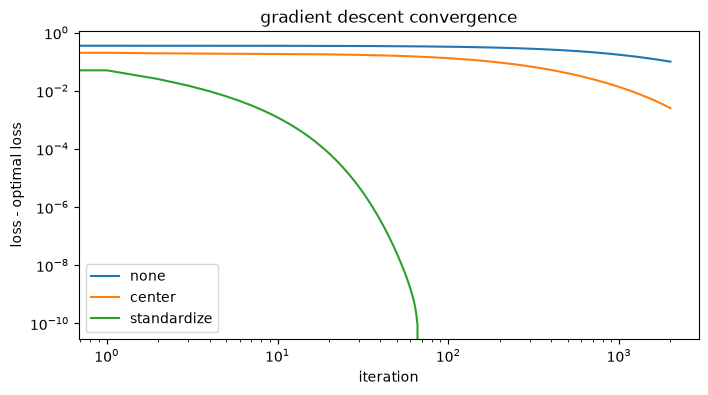

In [15]:
def gradient_descent(X, y, steps):
    Xa = np.c_[np.ones(len(X)), X]                       # intercept column
    lr = 4 / np.linalg.eigvalsh(Xa.T @ Xa / len(X)).max()
    theta = np.zeros(Xa.shape[1])
    losses = []
    for _ in range(steps):
        z = Xa @ theta
        losses.append(point_loss(1, 0, z, y).mean())
        theta -= lr * Xa.T @ (sigmoid(z) - y) / len(X)
    return np.array(losses)


X_gd = change_units(Xm, 10, offset=20)                   # moderate scale and offset
best = LogisticRegression(C=np.inf).fit(X_gd, ym)
best_loss = point_loss(1, 0, best.decision_function(X_gd), ym).mean()

fig, ax = plt.subplots(figsize=(8, 4))
for method in ["none", "center", "standardize"]:
    P, _ = preprocess(X_gd, X_gd, method)
    ax.plot(gradient_descent(P, ym, 2000) - best_loss, label=method)
ax.set(xscale="log", yscale="log", xlabel="iteration", ylabel="loss - optimal loss",
       title="gradient descent convergence")
ax.legend()
plt.show()

- Rank the three methods by convergence speed. What does centering contribute on its own?
- All three runs converge to the same model in the end (logistic regression without penalty is invariant to these
  transforms). So why bother? Think about large datasets and regularized models, where the penalty on $\|w\|$
  depends on the units of each feature.

## Summary

- Logistic regression is a linear model of the log-odds, passed through a sigmoid to give probabilities.
- It is fit by minimizing cross-entropy, a convex loss, usually with gradient-based methods.
- $w$ sets the boundary orientation and the confidence; regularization shrinks it; the threshold moves the boundary.
- KNN depends on distances, so feature scale decides which features matter. Always scale before KNN.
- Centering does not affect KNN, but it improves the conditioning of gradient descent.
- Fit preprocessing on the training set only (use a `Pipeline`).